# S08 - Démonstration 3: Tweets

![Airline_tweets](https://raw.githubusercontent.com/acedesci/scanalytics/refs/heads/master/EN/S07_Intro_ML/data/illustration_v2.jpg)

In [1]:
# ==========================================
# IMPORTS ET CONFIGURATION
# ==========================================
# Importer pandas pour la manipulation et l'analyse de données
import pandas as pd
# Importer numpy pour les opérations numériques, en particulier sur les tableaux
import numpy as np
# Importer matplotlib.pyplot pour les fonctionnalités de base de tracé
import matplotlib.pyplot as plt
# Importer seaborn pour la visualisation avancée de données
import seaborn as sns

# Scikit-Learn (apprentissage automatique classique) — bibliothèque d'apprentissage automatique en Python
from sklearn.model_selection import train_test_split # Sert à séparer les données en ensembles d'entraînement et de test
from sklearn.feature_extraction.text import TfidfVectorizer # Sert à convertir des données textuelles en caractéristiques numériques TF-IDF
from sklearn.tree import DecisionTreeClassifier # Sert à construire un modèle de classification par arbre de décision
from sklearn.linear_model import LogisticRegression  # Modèle linéaire de référence pour la classification
from sklearn.metrics import classification_report # Sert à évaluer la performance d'un modèle de classification
from sklearn.preprocessing import LabelEncoder # Sert à encoder des étiquettes catégoriques en format numérique

# LightGBM (gradient boosting) — cadre de gradient boosting très performant
import lightgbm as lgb # Sert à construire un modèle de classification LightGBM

# Apprentissage profond (Keras/TensorFlow) — bibliothèques pour construire et entraîner des réseaux de neurones
import tensorflow as tf # Bibliothèque centrale TensorFlow
from tensorflow.keras.models import Sequential # Sert à construire des modèles séquentiels Keras
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalAveragePooling1D # Diverses couches Keras pour les réseaux de neurones
from tensorflow.keras.preprocessing.text import Tokenizer # Sert à convertir le texte en séquences d'entiers
from tensorflow.keras.preprocessing.sequence import pad_sequences # Sert à compléter (padding) les séquences à une longueur uniforme

## Bloc 1: chargement des données

In [2]:

# ==========================================
# 1. CHARGEMENT DES DONNÉES (tweets de compagnies aériennes)
# ==========================================
print("Téléchargement du jeu de données...")
# URL du jeu de données à télécharger
url = "https://raw.githubusercontent.com/acedesci/scanalytics/refs/heads/master/EN/S07_Intro_ML/data/tweets_data_filtered.csv"
# Lire le fichier CSV à partir de l'URL dans un DataFrame pandas
df = pd.read_csv(url)
# Afficher tout le DataFrame (ou son début s'il est très volumineux)
df

Téléchargement du jeu de données...


,text,category
0,plus you've added commercials to the experienc...,Satisfied
1,"yes, nearly every time I fly VX this “ear worm...",Satisfied
2,"Well, I didn't…but NOW I DO! :-D",Satisfied
3,"it was amazing, and arrived an hour early. You...",Satisfied
4,I &lt;3 pretty graphics. so much better than m...,Satisfied
...,...,...
5594,Thank you. “: Customer Relations will review ...,Satisfied
5595,Thanks! He is.,Satisfied
5596,"my flight was cancelled, leaving tomorrow morn...",Flight Issue
5597,right on cue with the delays👌,Flight Issue


## Bloc 2: préparation et ingénierie des caractéristiques

### Caractéristiques TF-IDF (Term Frequency - Inverse Document Frequency) pour les données textuelles

Nous utilisons la ligne de code suivante pour traiter le texte:
`TfidfVectorizer(stop_words='english', max_features=1000)`

Voici ce qu'elle fait:
* **`TfidfVectorizer`:** cet outil convertit les mots en nombres (valeurs). Plutôt que de simplement les compter, il leur attribue un « score d'unicité ».
    * Les **mots fréquents** reçoivent un score faible.
    * Les **mots rares** reçoivent un score élevé.
* **`stop_words='english'`:** indique à l'ordinateur d'ignorer les mots grammaticaux courants sans signification, comme *"the"*, *"is"*, *"and"*, *"of"*.
* **`max_features=1000`:** force le modèle à se concentrer uniquement sur les **1 000 mots les plus importants** du jeu de données. Les coquilles rares ou les mots non pertinents sont ignorés.

---

### Comment le score TF-IDF est-il calculé ?
Le score TF-IDF est le produit de deux nombres: la **fréquence du terme (TF)** et la **fréquence inverse de document (IDF)**.

$$\text{TF-IDF} = \text{TF} \times \text{IDF}$$

#### Étape 1: fréquence du terme (TF)
*« À quelle fréquence le mot apparaît-il dans CE texte précis ? »*
Si un client écrit « late » 5 fois, ce mot est très important pour ce courriel précis.

$$\text{TF} = \frac{\text{nombre d'occurrences du mot dans le document}}{\text{nombre total de mots dans le document}}$$

#### Étape 2: fréquence inverse de document (IDF)
*« À quel point ce mot est-il rare dans l'ensemble des points de données (tweets) ? »* C'est la pénalité pour les mots génériques.
* Si un mot apparaît dans **chaque** tweet, l'IDF est **faible** (proche de 0).
* Si un mot n'apparaît que dans **un seul** tweet (p. ex. « shattered »), l'IDF est **élevée**.

$$\text{IDF} = \ln \left( \frac{1+\text{nombre total de documents}}{1+\text{nombre de documents contenant le mot}} \right)+1$$

#### Un exemple simple
À partir des 3 courts tweets suivants:
1.  **Doc A:** "Delivery late"
2.  **Doc B:** "Delivery fast"
3.  **Doc C:** "Package lost"

**Pourquoi « Late » obtient-il un score plus élevé que « Delivery » ?**

| Mot | Présent dans | Logique | Score |
| :--- | :--- | :--- | :--- |
| **"Delivery"** | Doc A et Doc B | Il est **plus fréquent** (présent dans 2/3 des documents). Le modèle le juge moins important. | **0.644** |
| **"Late"** | Doc A uniquement | Il est **plus unique** (présent dans 1/3 des documents). Le modèle le retient comme un signal clé. | **0.847** |

**Note:**
*  « Delivery (Tweet A) »: $\text{TF} = 0.5, \text{IDF} = \ln\left( \frac{1+3}{1+2} \right)+1=1.288, \text{TF-IDF} = 0.5\times1.288 = 0.644$
*  « Late (Tweet A) »: $\text{TF} = 0.5, \text{IDF} = \ln\left( \frac{1+3}{1+1} \right)+1=1.693, \text{TF-IDF} = 0.5\times1.693 = 0.847$


**Résultat:** le modèle ignore le sujet générique (« Delivery ») et se concentre uniquement sur le problème (« Late »).

In [3]:
# ==========================================
# PRÉTRAITEMENT ET SÉPARATION
# ==========================================
# Initialiser LabelEncoder pour convertir les étiquettes catégoriques en valeurs numériques
le = LabelEncoder()
# Appliquer LabelEncoder à la colonne 'category' pour créer des étiquettes numériques
df['label'] = le.fit_transform(df['category'])
# Déterminer le nombre de classes uniques après l'encodage
num_classes = len(le.classes_)

# Séparer le jeu de données en ensembles d'entraînement et de test
# X_train_text, X_test_text: données textuelles pour l'entraînement et le test
# y_train, y_test: étiquettes numériques correspondantes pour l'entraînement et le test
# test_size=0.2: 20 % des données pour le test, 80 % pour l'entraînement
# random_state=42: assure la reproductibilité de la séparation
# stratify=df['label']: assure que la proportion des classes est la même dans les ensembles d'entraînement et de test
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

# Afficher le nombre d'observations dans les ensembles d'entraînement et de test
print(f"\nEntraînement sur {len(X_train_text)} observations | Test sur {len(X_test_text)} observations")

# ==========================================
# 3. INGÉNIERIE DES CARACTÉRISTIQUES (TF-IDF)
# ==========================================
# Partagée par les modèles d'arbre, de régression logistique et LightGBM
# Initialiser TfidfVectorizer:
# stop_words='english': retire les mots vides courants en anglais (p. ex. 'the', 'is', 'a')
# max_features=1000: ne conserve que les 1000 mots ou termes les plus fréquents
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)

# Ajuster le vectoriseur TF-IDF sur les données textuelles d'entraînement et les transformer en matrice TF-IDF
# .toarray() convertit la matrice creuse en tableau NumPy dense
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()

# Transformer les données textuelles de test à l'aide du vectoriseur TF-IDF *déjà ajusté*
X_test_tfidf = tfidf.transform(X_test_text).toarray()


Entraînement sur 4479 observations | Test sur 1120 observations


In [4]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# NOTE: cette partie du code est facultative. Elle sert à afficher et à exporter les caractéristiques d'entrée TF-IDF
# Créer un DataFrame contenant les 100 premières lignes des données d'entraînement TF-IDF à afficher
# Obtenir les noms des caractéristiques (mots) du vectoriseur TF-IDF
feature_names = tfidf.get_feature_names_out()
# Créer un DataFrame pandas à partir des 50 premières lignes de X_train_tfidf, en utilisant feature_names comme noms de colonnes
tfidf_df = pd.DataFrame(X_train_tfidf[:50], columns=feature_names)
# Définir le nom du fichier pour sauvegarder l'échantillon TF-IDF en CSV
csv_filename = 'tfidf_sample.csv'
# Sauvegarder l'échantillon TF-IDF en CSV sans l'index
tfidf_df.to_csv(csv_filename, index=False)

if IN_COLAB:
    files.download(csv_filename)  # Télécharger le fichier CSV généré sur la machine locale (propre à Google Colab)
else:
    print(f"Fichier sauvegardé sur disque: {csv_filename}")

# Afficher le DataFrame TF-IDF
tfidf_df

Fichier sauvegardé sur disque: tfidf_sample.csv


,000,10,100,1000,11,12,13,14,15,16,...,ya,yall,yeah,year,years,yep,yes,yesterday,yr,yyz
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Blocs 3 et 4: modèles d'apprentissage automatique — entraînement et validation

### Modèle A: arbre de décision

In [5]:
# --- Modèle A: arbre de décision ---
print("\n--- Entraînement du modèle A: arbre de décision ---")
# Initialiser le classificateur d'arbre de décision avec une profondeur maximale de 10 et un état aléatoire fixe pour la reproductibilité
tree_model = DecisionTreeClassifier(max_depth=10, random_state=42)
# Entraîner le modèle d'arbre de décision sur les données d'entraînement transformées par TF-IDF et leurs étiquettes
tree_model.fit(X_train_tfidf, y_train)
# Faire des prédictions sur les données de test transformées par TF-IDF
tree_preds = tree_model.predict(X_test_tfidf)
# Afficher le rapport de classification (précision, rappel, score F1 et support par classe)
print(classification_report(y_test, tree_preds, target_names=le.classes_))


--- Entraînement du modèle A: arbre de décision ---
               precision    recall  f1-score   support

 Flight Issue       0.85      0.60      0.71       502
Luggage Issue       0.81      0.70      0.75       145
    Satisfied       0.66      0.89      0.76       473

     accuracy                           0.74      1120
    macro avg       0.77      0.73      0.74      1120
 weighted avg       0.77      0.74      0.73      1120



### Modèle B: régression logistique

In [6]:
# --- Modèle B: régression logistique ---
print("\n--- Entraînement du modèle B: régression logistique ---")
# Excellente référence pour le texte. Une frontière linéaire suffit souvent pour les « mots-clés ».
# Initialiser le modèle de régression logistique avec un maximum de 1000 itérations et un état aléatoire fixe
lr_model = LogisticRegression(max_iter=1000, random_state=42)
# Entraîner le modèle de régression logistique sur les données d'entraînement transformées par TF-IDF et leurs étiquettes
lr_model.fit(X_train_tfidf, y_train)
# Faire des prédictions sur les données de test transformées par TF-IDF
lr_preds = lr_model.predict(X_test_tfidf)
# Afficher le rapport de classification
print(classification_report(y_test, lr_preds, target_names=le.classes_))


--- Entraînement du modèle B: régression logistique ---
               precision    recall  f1-score   support

 Flight Issue       0.87      0.91      0.89       502
Luggage Issue       0.89      0.74      0.81       145
    Satisfied       0.89      0.89      0.89       473

     accuracy                           0.88      1120
    macro avg       0.88      0.85      0.86      1120
 weighted avg       0.88      0.88      0.88      1120



### Modèle C: LightGBM

In [7]:
# --- Modèle C: LightGBM ---
print("\n--- Entraînement du modèle C: LightGBM ---")
# Gradient boosting: souvent le plus performant sur des données tabulaires ou creuses.
# Nous utilisons l'enveloppe Scikit-Learn de LightGBM pour simplifier
# Initialiser le classificateur LightGBM avec un état aléatoire fixe et désactiver les sorties verbeuses
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
# Entraîner le modèle LightGBM sur les données d'entraînement transformées par TF-IDF et leurs étiquettes
lgb_model.fit(X_train_tfidf, y_train)
# Faire des prédictions sur les données de test transformées par TF-IDF
lgb_preds = lgb_model.predict(X_test_tfidf)
# Afficher le rapport de classification
print(classification_report(y_test, lgb_preds, target_names=le.classes_))




--- Entraînement du modèle C: LightGBM ---
               precision    recall  f1-score   support

 Flight Issue       0.88      0.86      0.87       502
Luggage Issue       0.80      0.79      0.80       145
    Satisfied       0.87      0.89      0.88       473

     accuracy                           0.87      1120
    macro avg       0.85      0.85      0.85      1120
 weighted avg       0.87      0.87      0.87      1120



/Users/martincousineau/miniconda3/envs/scanalytics/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### (Complément) Modèle D: apprentissage profond avec couche d'embedding
(NOTE: le détail du modèle n'est pas couvert dans ce cours, car il nécessite une compréhension plus approfondie de la structure des couches d'un modèle d'apprentissage profond)

#### Note: qu'est-ce qu'une couche d'« embedding » ?

En termes simples, la **couche d'embedding** agit comme un **traducteur intelligent**. Lorsqu'on tokenise le texte, on transforme les mots en entiers:
* "Late" $\rightarrow$ 45
* "Delayed" $\rightarrow$ 982
* "Happy" $\rightarrow$ 12

Pour un ordinateur, **45** et **982** semblent sans rapport. Les calculs supposent que « Delayed » (982) est beaucoup « plus grand » que « Late » (45), ce qui est faux puisqu'ils ont le même sens.


La couche d'embedding attribue à chaque mot une position précise sur une carte multidimensionnelle (un vecteur de nombres). Plutôt que `45`, le mot **« Late »** devient une liste de coordonnées, par exemple: `[0.2, -0.5, 0.9, ...]`

**L'embedding dans l'apprentissage profond:**
Pendant l'entraînement, le modèle rapproche sur cette carte les mots de sens proche.
* **« Late »** et **« Delayed »** finissent avec des coordonnées très semblables.
* **« Late »** et **« Happy »** finissent éloignés.

Par exemple, après l'entraînement, en projetant les mots sur une carte 2D (deux coordonnées):

| Mot | Dimension A (positivité) | Dimension B (urgence) |
| :--- | :--- | :--- |
| **"Late"** | -0.9 (négatif) | 0.9 (élevée) |
| **"Delayed"** | -0.8 (négatif) | 0.9 (élevée) |
| **"Good"** | 0.9 (positif) | 0.1 (faible) |

On voit que « Late » et « Delayed » ont presque les mêmes valeurs. Cela aide le modèle d'apprentissage profond à comprendre qu'ils sont synonymes. Cette transformation est directement intégrée au modèle d'apprentissage profond pendant l'entraînement (c'est-à-dire que l'ingénierie des caractéristiques est effectuée **automatiquement** plutôt que précalculée comme pour TF-IDF).

In [8]:
# --- Modèle D: apprentissage profond (embeddings) ---
print("\n--- Entraînement du modèle D: apprentissage profond ---")
# Prétraitement propre à l'apprentissage profond
# Définir la taille du vocabulaire pour le Tokenizer
vocab_size = 2000
# Définir la dimension des vecteurs d'embedding
embedding_dim = 16
# Définir la longueur maximale des séquences d'entrée
max_length = 30
# Définir le type de troncature ('post' = troncature à partir de la fin)
trunc_type = 'post'

# Initialiser le Tokenizer avec la taille de vocabulaire spécifiée et un jeton hors-vocabulaire
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
# Ajuster le tokenizer sur les données textuelles d'entraînement pour construire l'index des mots
tokenizer.fit_on_texts(X_train_text)

# Convertir le texte d'entraînement en séquences d'entiers
train_sequences = tokenizer.texts_to_sequences(X_train_text)
# Convertir le texte de test en séquences d'entiers
test_sequences = tokenizer.texts_to_sequences(X_test_text)

# Compléter (padding) les séquences d'entraînement à une longueur uniforme (max_length)
train_padded = pad_sequences(train_sequences, maxlen=max_length, truncating=trunc_type)
# Compléter (padding) les séquences de test à une longueur uniforme (max_length)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type)

# Construire le modèle d'apprentissage profond (modèle séquentiel Keras)
dl_model = Sequential([
    # Couche d'embedding: convertit les mots encodés en entiers en vecteurs denses de taille fixe
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    # Couche GlobalAveragePooling1D: moyenne les vecteurs d'embedding sur la dimension de la séquence
    GlobalAveragePooling1D(),
    # Couche Dense avec 24 unités et fonction d'activation ReLU
    Dense(24, activation='relu'),
    # Couche Dropout: met aléatoirement à 0 une fraction des unités d'entrée à chaque mise à jour pendant l'entraînement pour éviter le surapprentissage
    Dropout(0.5),
    # Couche Dense de sortie avec 'num_classes' unités et activation 'softmax' pour les probabilités de classification multi-classes
    Dense(num_classes, activation='softmax')
])

# Compiler le modèle:
# loss='sparse_categorical_crossentropy': adapté aux étiquettes encodées en entiers
# optimizer='adam': algorithme d'optimisation à taux d'apprentissage adaptatif
# metrics=['accuracy']: métrique à suivre pendant l'entraînement et l'évaluation
dl_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Entraîner le modèle d'apprentissage profond:
# epochs=20: nombre de passages sur l'ensemble du jeu d'entraînement
# validation_data=(test_padded, y_test): données utilisées pour évaluer la perte et les métriques à la fin de chaque époque
# verbose=0: supprime les sorties d'entraînement
dl_model.fit(train_padded, y_train, epochs=20, validation_data=(test_padded, y_test), verbose=0)

# Évaluer le modèle d'apprentissage profond entraîné sur les données de test
loss, accuracy = dl_model.evaluate(test_padded, y_test, verbose=0)
# Afficher la justesse du modèle d'apprentissage profond
print(f"Justesse de l'apprentissage profond: {accuracy*100:.2f} %")
# Faire des prédictions avec le modèle d'apprentissage profond sur les données de test
# np.argmax convertit la distribution de probabilités en étiquettes de classe
dl_preds = np.argmax(dl_model.predict(test_padded, verbose=0), axis=1)
# Afficher le rapport de classification pour le modèle d'apprentissage profond
print(classification_report(y_test, dl_preds, target_names=le.classes_))

/Users/martincousineau/miniconda3/envs/scanalytics/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



--- Entraînement du modèle D: apprentissage profond ---
Justesse de l'apprentissage profond: 88.30 %
               precision    recall  f1-score   support

 Flight Issue       0.88      0.92      0.90       502
Luggage Issue       0.81      0.77      0.79       145
    Satisfied       0.91      0.88      0.90       473

     accuracy                           0.88      1120
    macro avg       0.87      0.86      0.86      1120
 weighted avg       0.88      0.88      0.88      1120



Exécutez le code ci-dessous si vous souhaitez afficher l'illustration du modèle de réseau de neurones ci-dessus.

Génération du diagramme de l'architecture du modèle...


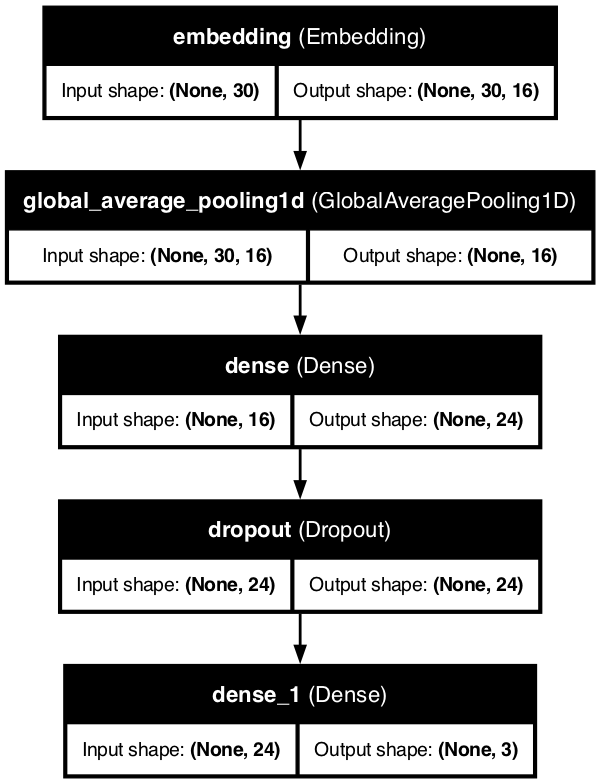

In [9]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

# Le dl_model a déjà été construit et entraîné dans la cellule précédente,
# l'appel explicite à .build() ici n'est donc pas nécessaire. Nous pouvons retirer cette ligne.
# dl_model.build(input_shape=(None, max_length))

# ============================================
# GÉNÉRATION DU DIAGRAMME
# ============================================
print("Génération du diagramme de l'architecture du modèle...")

plot_path = 'model_architecture.png'

# Tracer le modèle d'apprentissage profond (dl_model)
plot_model(dl_model,
           to_file=plot_path,
           show_shapes=True,      # Affiche les entrées/sorties (p. ex. 30 mots -> 16 nombres)
           show_layer_names=True, # Affiche les noms personnalisés définis ci-dessus
           rankdir='TB',          # TB = sens haut vers bas
           dpi=100                # Résolution de l'image
)

# Afficher l'image directement
display(Image(plot_path))

## Prédiction: démonstration en direct selon le texte saisi
(ce widget a été codé en mode « vibe coding » à l'aide de Gemini 😏)

In [10]:
# Widget Python interactif
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================
# WIDGET INTERACTIF
# ==========================================
print("\n" + "="*40)
print("CLASSIFICATEUR INTERACTIF (avec scores de confiance)")
print("="*40)

text_input = widgets.Text(
    value='',
    placeholder='Tapez un message à analyser...',
    description='Texte:',
    disabled=False
)

out = widgets.Output()

def get_prediction_and_confidence(model, vector):
    # predict_proba retourne un tableau comme [[0.1, 0.8, 0.1]]
    probs = model.predict_proba(vector)[0]
    idx = np.argmax(probs)
    label = le.classes_[idx]
    confidence = np.max(probs) * 100
    return label, confidence

def on_text_submit(change):
    with out:
        clear_output()
        input_text = change.new
        if not input_text: return

        print(f"Analyse de: '{input_text}'\n" + "-"*30)

        # Prétraitement
        vec = tfidf.transform([input_text]).toarray()

        # 1. Arbre
        # Les arbres peuvent fournir des probabilités (fraction d'observations dans la feuille)
        t_lbl, t_conf = get_prediction_and_confidence(tree_model, vec)
        print(f"🌲 Arbre de décision:    [{t_lbl}] (Conf: {t_conf:.1f} %)")

        # 2. Régression logistique
        lr_lbl, lr_conf = get_prediction_and_confidence(lr_model, vec)
        print(f"📈 Régression logistique: [{lr_lbl}] (Conf: {lr_conf:.1f} %)")

        # 3. LightGBM
        gb_lbl, gb_conf = get_prediction_and_confidence(lgb_model, vec)
        print(f"🚀 LightGBM:             [{gb_lbl}] (Conf: {gb_conf:.1f} %)")

        # 4. Apprentissage profond
        seq = tokenizer.texts_to_sequences([input_text])
        padded = pad_sequences(seq, maxlen=max_length)
        dl_probs = dl_model.predict(padded, verbose=0)[0]
        dl_idx = np.argmax(dl_probs)
        dl_conf = np.max(dl_probs) * 100
        print(f"🧠 Apprentissage profond: [{le.classes_[dl_idx]}] (Conf: {dl_conf:.1f} %)")

text_input.observe(on_text_submit, names='value')
display(text_input)
display(out)



CLASSIFICATEUR INTERACTIF (avec scores de confiance)


Text(value='', description='Texte:', placeholder='Tapez un message à analyser...')

Output()